<a href="https://colab.research.google.com/github/marcelazam/Alura-Store-/blob/main/TelecomX%20analisis_de_evasion_de_clientes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import pandas as pd

df = pd.read_json("TelecomX_Data.json")

df.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


In [6]:
import pandas as pd

df = pd.read_json("TelecomX_Data.json")

customer = pd.json_normalize(df["customer"])
phone = pd.json_normalize(df["phone"])
internet = pd.json_normalize(df["internet"])
account = pd.json_normalize(df["account"])

df = pd.concat(
    [df[["customerID", "Churn"]], customer, phone, internet, account],
    axis=1
)

df.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [7]:
df = df.drop(columns=["customerID"])

df.head()

,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,No,Female,0,Yes,Yes,9,Yes,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,No,Male,0,No,No,9,Yes,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,Yes,Male,0,No,No,4,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,No,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [8]:
df = pd.get_dummies(df, drop_first=True)

df.head()

,SeniorCitizen,tenure,Charges.Monthly,Churn_No,Churn_Yes,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,Charges.Total_995.35,Charges.Total_996.45,Charges.Total_996.85,Charges.Total_996.95,Charges.Total_997.65,Charges.Total_997.75,Charges.Total_998.1,Charges.Total_999.45,Charges.Total_999.8,Charges.Total_999.9
0,0,9,65.6,True,False,False,True,True,True,False,...,False,False,False,False,False,False,False,False,False,False
1,0,9,59.9,True,False,True,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
2,0,4,73.9,False,True,True,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
3,1,13,98.0,False,True,True,True,False,True,False,...,False,False,False,False,False,False,False,False,False,False
4,1,3,83.9,False,True,False,True,False,True,False,...,False,False,False,False,False,False,False,False,False,False


In [10]:
import pandas as pd

# cargar
df = pd.read_json("TelecomX_Data.json")

# normalizar
customer = pd.json_normalize(df["customer"])
phone = pd.json_normalize(df["phone"])
internet = pd.json_normalize(df["internet"])
account = pd.json_normalize(df["account"])

df = pd.concat(
    [df[["customerID", "Churn"]], customer, phone, internet, account],
    axis=1
)

# eliminar ID
df = df.drop(columns=["customerID"])

# asegurar numéricas
df["Charges.Total"] = pd.to_numeric(df["Charges.Total"], errors="coerce")
df["Charges.Monthly"] = pd.to_numeric(df["Charges.Monthly"], errors="coerce")

# encoding SOLO al final
df = pd.get_dummies(df, drop_first=True)

df.head()

,SeniorCitizen,tenure,Charges.Monthly,Charges.Total,Churn_No,Churn_Yes,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,9,65.6,593.30,True,False,False,True,True,True,...,False,True,False,False,True,False,True,False,False,True
1,0,9,59.9,542.40,True,False,True,False,False,True,...,False,False,False,True,False,False,False,False,False,True
2,0,4,73.9,280.85,False,True,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
3,1,13,98.0,1237.85,False,True,True,True,False,True,...,False,True,False,True,False,False,True,False,True,False
4,1,3,83.9,267.40,False,True,False,True,False,True,...,False,True,False,False,False,False,True,False,False,True


In [12]:
df["Churn_Yes"].mean()

np.float64(0.257190037154259)

In [13]:
from sklearn.preprocessing import StandardScaler

cols_numericas = ["tenure", "Charges.Monthly", "Charges.Total"]

scaler = StandardScaler()
df[cols_numericas] = scaler.fit_transform(df[cols_numericas])

df.head()

,SeniorCitizen,tenure,Charges.Monthly,Charges.Total,Churn_No,Churn_Yes,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,-0.950200,0.029206,-0.743818,True,False,False,True,True,True,...,False,True,False,False,True,False,True,False,False,True
1,0,-0.950200,-0.159990,-0.766256,True,False,True,False,False,True,...,False,False,False,True,False,False,False,False,False,True
2,0,-1.153700,0.304702,-0.881554,False,True,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
3,1,-0.787401,1.104635,-0.459685,False,True,True,True,False,True,...,False,True,False,True,False,False,True,False,True,False
4,1,-1.194400,0.636624,-0.887483,False,True,False,True,False,True,...,False,True,False,False,False,False,True,False,False,True


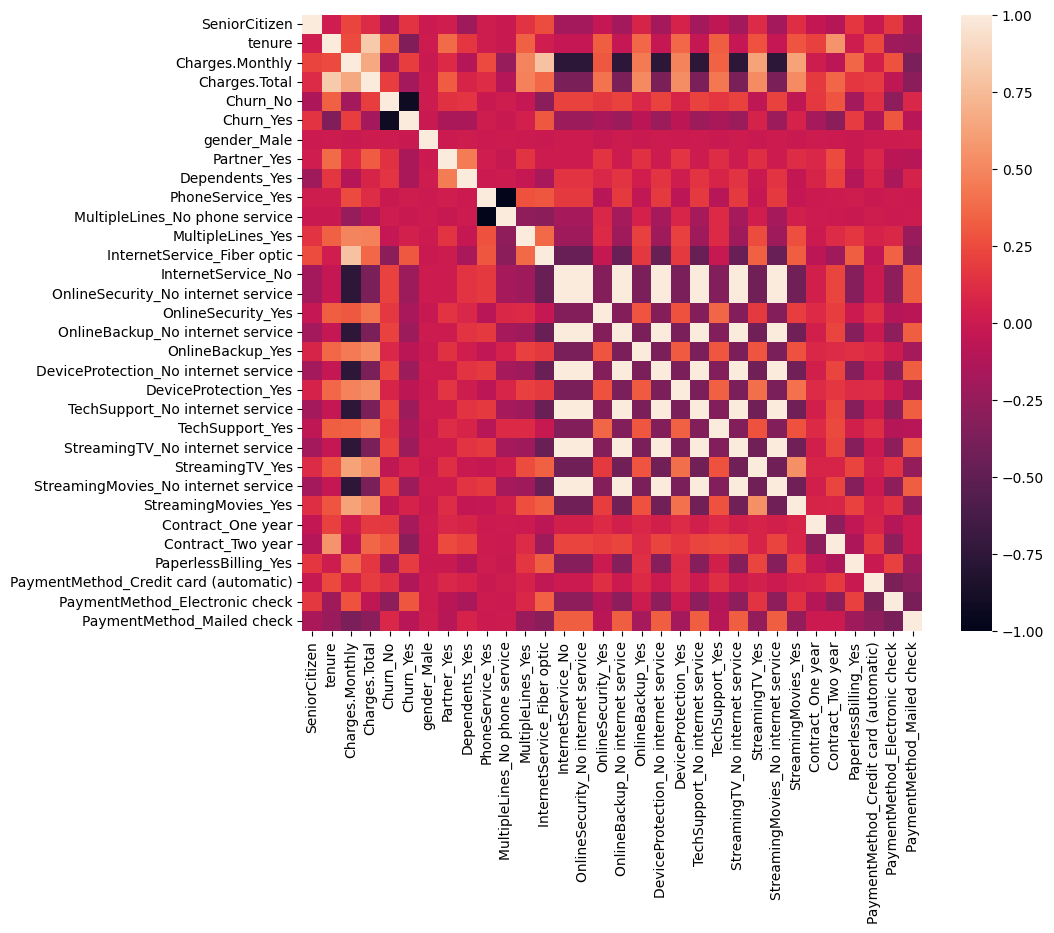

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=False)
plt.show()

In [15]:
df.corr()["Churn_Yes"].sort_values(ascending=False)

,Churn_Yes
Churn_Yes,1.000000
InternetService_Fiber optic,0.300949
PaymentMethod_Electronic check,0.294626
Charges.Monthly,0.189866
PaperlessBilling_Yes,0.186666
SeniorCitizen,0.146733
StreamingTV_Yes,0.062430
StreamingMovies_Yes,0.060586
MultipleLines_Yes,0.039343
PhoneService_Yes,0.012571


<Figure size 640x480 with 0 Axes>

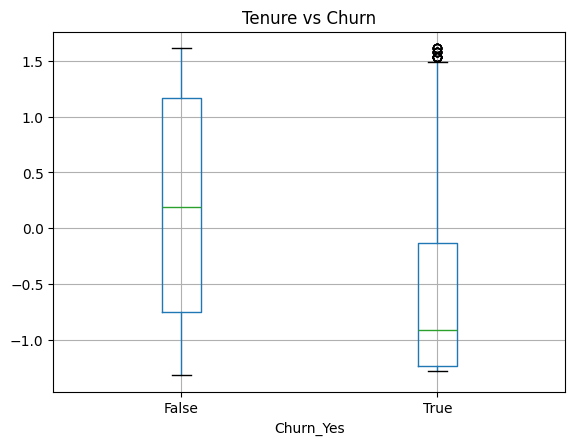

<Figure size 640x480 with 0 Axes>

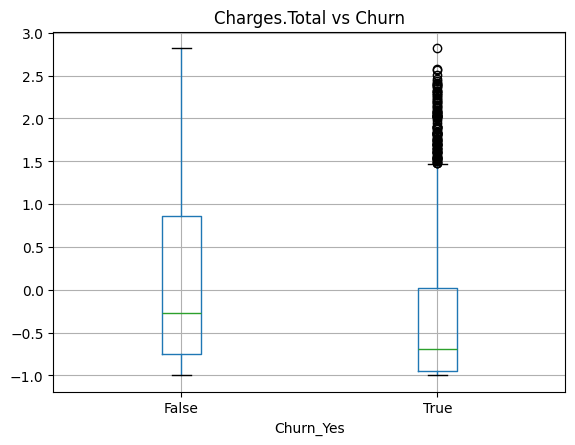

In [16]:
import matplotlib.pyplot as plt

# Tenure vs Churn (boxplot)
plt.figure()
df.boxplot(column="tenure", by="Churn_Yes")
plt.suptitle("")
plt.title("Tenure vs Churn")
plt.show()

# Charges.Total vs Churn (boxplot)
plt.figure()
df.boxplot(column="Charges.Total", by="Churn_Yes")
plt.suptitle("")
plt.title("Charges.Total vs Churn")
plt.show()

In [17]:
from sklearn.model_selection import train_test_split

# Variables y target
X = df.drop(columns=["Churn_Yes", "Churn_No"])
y = df["Churn_Yes"]

# División 70/30
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

X_train.shape, X_test.shape

((5086, 30), (2181, 30))

In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# --- Modelo 1: Regresión Logística ---
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)
y_pred_log = log_model.predict(X_test)

# Métricas
print("Regresión Logística:")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))

# --- Modelo 2: Random Forest ---
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

# Métricas
print("Random Forest:")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

ValueError: Input X contains NaN.
LogisticRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [19]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="mean")
X_train = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns)
X_test = pd.DataFrame(imputer.transform(X_test), columns=X_test.columns)

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# --- Modelo 1: Regresión Logística ---
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)
y_pred_log = log_model.predict(X_test)

# Métricas
print("Regresión Logística:")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))

# --- Modelo 2: Random Forest ---
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

# Métricas
print("Random Forest:")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Regresión Logística:
Accuracy: 0.8010087116001834
              precision    recall  f1-score   support

       False       0.85      0.89      0.87      1620
        True       0.63      0.53      0.58       561

    accuracy                           0.80      2181
   macro avg       0.74      0.71      0.72      2181
weighted avg       0.79      0.80      0.80      2181

Random Forest:
Accuracy: 0.7831270059605685
              precision    recall  f1-score   support

       False       0.83      0.89      0.86      1620
        True       0.60      0.47      0.53       561

    accuracy                           0.78      2181
   macro avg       0.71      0.68      0.69      2181
weighted avg       0.77      0.78      0.77      2181



In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# --- Modelo 1: Regresión Logística ---
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)
y_pred_log = log_model.predict(X_test)

# Métricas
print("=== Regresión Logística ===")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))

# --- Modelo 2: Random Forest ---
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

# Métricas
print("=== Random Forest ===")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

=== Regresión Logística ===
Accuracy: 0.8010087116001834
              precision    recall  f1-score   support

       False       0.85      0.89      0.87      1620
        True       0.63      0.53      0.58       561

    accuracy                           0.80      2181
   macro avg       0.74      0.71      0.72      2181
weighted avg       0.79      0.80      0.80      2181

=== Random Forest ===
Accuracy: 0.7831270059605685
              precision    recall  f1-score   support

       False       0.83      0.89      0.86      1620
        True       0.60      0.47      0.53       561

    accuracy                           0.78      2181
   macro avg       0.71      0.68      0.69      2181
weighted avg       0.77      0.78      0.77      2181



In [22]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Random Forest Metrics:")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1-score:", f1_score(y_test, y_pred_rf))

Random Forest Metrics:
Accuracy: 0.7831270059605685
Precision: 0.5995475113122172
Recall: 0.47237076648841353
F1-score: 0.5284147557328016


In [23]:
from sklearn.metrics import confusion_matrix

# Regresión Logística
cm_log = confusion_matrix(y_test, y_pred_log)
print("Matriz de Confusión - Regresión Logística:")
print(cm_log)

# Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)
print("Matriz de Confusión - Random Forest:")
print(cm_rf)

Matriz de Confusión - Regresión Logística:
[[1448  172]
 [ 262  299]]
Matriz de Confusión - Random Forest:
[[1443  177]
 [ 296  265]]


In [24]:
import pandas as pd
import numpy as np

coef_df = pd.DataFrame({
    "Variable": X_train.columns,
    "Coeficiente": log_model.coef_[0]
}).sort_values(by="Coeficiente", key=abs, ascending=False)

coef_df.head(10)

,Variable,Coeficiente
1,tenure,-1.343483
25,Contract_Two year,-1.235464
10,InternetService_Fiber optic,1.067808
24,Contract_One year,-0.654752
3,Charges.Total,0.622624
2,Charges.Monthly,-0.422020
26,PaperlessBilling_Yes,0.386548
23,StreamingMovies_Yes,0.366253
28,PaymentMethod_Electronic check,0.335262
9,MultipleLines_Yes,0.332232


In [25]:
import pandas as pd
import numpy as np

coef_df = pd.DataFrame({
    "Variable": X_train.columns,
    "Coeficiente": log_model.coef_[0]
}).sort_values(by="Coeficiente", key=abs, ascending=False)

coef_df.head(10)

,Variable,Coeficiente
1,tenure,-1.343483
25,Contract_Two year,-1.235464
10,InternetService_Fiber optic,1.067808
24,Contract_One year,-0.654752
3,Charges.Total,0.622624
2,Charges.Monthly,-0.422020
26,PaperlessBilling_Yes,0.386548
23,StreamingMovies_Yes,0.366253
28,PaymentMethod_Electronic check,0.335262
9,MultipleLines_Yes,0.332232


In [26]:
# Top 10 variables por importancia
rf_importance_df.head(10)

NameError: name 'rf_importance_df' is not defined

In [27]:
rf_importance_df = pd.DataFrame({
    "Variable": X_train.columns,
    "Importancia": rf_model.feature_importances_
}).sort_values(by="Importancia", ascending=False)

rf_importance_df.head(10)

,Variable,Importancia
3,Charges.Total,0.196365
2,Charges.Monthly,0.172702
1,tenure,0.166876
28,PaymentMethod_Electronic check,0.037879
10,InternetService_Fiber optic,0.036709
4,gender_Male,0.030160
13,OnlineSecurity_Yes,0.026698
25,Contract_Two year,0.025937
26,PaperlessBilling_Yes,0.025418
19,TechSupport_Yes,0.024278


# Conclusión y resumen ejecutivo
conclusion_text = """
=== Conclusión del Análisis y Modelado de Churn – Telecom X ===

Factores más influyentes:
- Tenure: clientes con más antigüedad tienden a no cancelar.
- Tipo de contrato: contratos largos (1 o 2 años) reducen churn.
- Gasto total y mensual: clientes con mayor gasto tienden a permanecer.
- Forma de pago: pagos electrónicos se asocian a mayor cancelación.
- Servicios adicionales: fibra óptica y facturación electrónica aumentan churn.
- Soporte y seguridad: contar con TechSupport y OnlineSecurity reduce churn.

Rendimiento de los modelos:
- Regresión Logística: Accuracy=0.80, F1-score (Churn)=0.58 → mejor para identificar clientes en riesgo.
- Random Forest: Accuracy=0.78, F1-score (Churn)=0.53 → captura bien clientes que no cancelan, pero subestima churners.

Observaciones:
- La clase de churn está desbalanceada (~25% churners), lo que explica F1 moderado.
- No se detecta overfitting evidente; ambos modelos generalizan razonablemente.

Estrategias de retención sugeridas:
- Incentivar contratos largos para nuevos clientes.
- Beneficios o promociones para clientes con fibra óptica y pagos electrónicos.
- Mejorar servicios de soporte y seguridad online.
- Monitorear clientes con baja antigüedad y bajo gasto para detectar riesgo temprano.
"""

# Mostrar la conclusión
print(conclusion_text)

# Resumen ejecutivo del análisis de Churn
resumen_ejecutivo = """
Resumen Ejecutivo – Telecom X:

1. Los clientes con mayor antigüedad y contratos largos tienen menor churn.
2. Gasto total, mensual y forma de pago (electrónica) influyen en la cancelación.
3. Servicios como TechSupport y OnlineSecurity ayudan a retener clientes.
4. Regresión Logística detecta mejor clientes en riesgo que Random Forest.
5. Estrategias: incentivar contratos largos, beneficios para clientes con fibra o pagos electrónicos, y monitorear clientes de alto riesgo.
"""

print(resumen_ejecutivo)

# Cierre breve del proyecto
print("Cierre del Proyecto: La estrategia de retención propuesta puede reducir significativamente la cancelación de clientes (Churn).")